# Final Project: SLM Fine-Tuning for Cyber Threat Text Classification
**Melih Can KÖK / 258273001026**  
**Advisor:** Dr. Ali Cetinkaya  

**Models:** SmolLM2-360M | TinyLlama-1.1B | Qwen2.5-1.5B | Gemma-2-2b-it  
**Method:** QLoRA Fine-Tuning  
**Primary Dataset:** mrmoor/cyber-threat-intelligence (CC BY 4.0)
**Supplementary Eval:** AI4Sec/cti-bench (CTI-TAA)

## 1. Mount Google Drive & Install Dependencies (Crash-Safe)
### 1. Google Drive bağlantısı ve bağımlılıkların yüklenmesi

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Drive kaydı
SAVE_DIR = '/content/drive/MyDrive/BDM_Final_Project'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(f'{SAVE_DIR}/outputs', exist_ok=True)
os.makedirs(f'{SAVE_DIR}/figures', exist_ok=True)
print(f"Kaydedilen konum: {SAVE_DIR}")

from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get('HF_TOKEN_WRITE').strip())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kaydedilen konum: /content/drive/MyDrive/BDM_Final_Project


In [ ]:
%%capture
!pip install -q transformers datasets peft trl bitsandbytes accelerate scikit-learn evaluate rouge_score huggingface_hub "torchao>=0.16.0"

## 1. Imports & Configuration
### 1. İçe Aktarmalar ve Yapılandırma

In [ ]:
import os, time, json, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
    BitsAndBytesConfig, TrainingArguments, Trainer)
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

SEEDS = [42, 123, 456]
MODELS = {
    'SmolLM2-360M':  'HuggingFaceTB/SmolLM2-360M',
    'TinyLlama-1.1B':'TinyLlama/TinyLlama-1.1B-Chat-v1.0',
    'Qwen2.5-1.5B':  'Qwen/Qwen2.5-1.5B',
    'Gemma-2-2b':    'google/gemma-2-2b-it'
}
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Load & Preprocess Primary Dataset (`mrmoor`)
### 2. Birincil Veri Kümesini Yükleme ve Ön İşleme

In [ ]:
raw = load_dataset('mrmoor/cyber-threat-intelligence')

from collections import Counter

def get_dominant_label(entities):
    if not entities:
        return 'O'
    labels = [ent['label'] for ent in entities if ent['label'] != 'O']
    if not labels:
        return 'O'
    return Counter(labels).most_common(1)[0][0]

def preprocess(example):
    example['label'] = get_dominant_label(example.get('entities', []))
    return example

ds = raw.map(preprocess)
split_name = 'train' if 'train' in ds else list(ds.keys())[0]
df = pd.DataFrame({'text': ds[split_name]['text'], 'label': ds[split_name]['label']})
df = df.dropna().drop_duplicates(subset='text').reset_index(drop=True)

# Filter out classes with too few samples to allow for stratified splitting
class_counts = df['label'].value_counts()
valid_classes = class_counts[class_counts >= 20].index
df = df[df['label'].isin(valid_classes)].reset_index(drop=True)

unique_labels = sorted(df['label'].unique())
label2id = {l: i for i, l in enumerate(unique_labels)}
id2label = {i: l for l, i in label2id.items()}
df['label'] = df['label'].map(label2id)
NUM_LABELS = len(label2id)

def make_splits(df, seed):
    X, y = df['text'].tolist(), df['label'].tolist()
    X_tr,X_tmp,y_tr,y_tmp = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    X_val,X_te,y_val,y_te = train_test_split(X_tmp,y_tmp,test_size=0.5,random_state=seed,stratify=y_tmp)
    return X_tr, X_val, X_te, y_tr, y_val, y_te

X_tr,X_val,X_te,y_tr,y_val,y_te = make_splits(df, SEEDS[0])
print(f'Train:{len(X_tr)} | Val:{len(X_val)} | Test:{len(X_te)}')

README.md:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

all.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/9732 [00:00<?, ? examples/s]

Map:   0%|          | 0/9732 [00:00<?, ? examples/s]

Train:6556 | Val:819 | Test:820


## 3. Zero-Shot Baseline
### 3. Zero-Shot Referans Modeli

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import traceback

CANDIDATE_LABELS = [id2label[i] for i in range(NUM_LABELS)]
baseline_file = f'{SAVE_DIR}/outputs/zero_shot_baseline.csv'
categories_str = ", ".join(CANDIDATE_LABELS)

if os.path.exists(baseline_file):
    baseline_df = pd.read_csv(baseline_file)
    baseline_results = baseline_df.to_dict('records')
    print("Zero-shot referans model yüklendi")
else:
    baseline_results = []
    for key, name in MODELS.items():
        print(f'\nZero-Shot: {key}')
        try:
            tokenizer = AutoTokenizer.from_pretrained(name, trust_remote_code=True)
            model = AutoModelForCausalLM.from_pretrained(
                name,
                device_map="auto",
                trust_remote_code=True,
                torch_dtype=torch.bfloat16
            )

            preds, t0 = [], time.time()
            for text in X_te[:200]:

                prompt = f"Categorize the following cyber threat text into exactly one of these categories: {categories_str}.\nText: {text}\nCategory:"

                inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)

                outputs = model.generate(
                    **inputs,
                    max_new_tokens=10,
                    temperature=0.1,
                    do_sample=False,
                    pad_token_id=tokenizer.eos_token_id
                )


                gen_text = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()


                predicted_label = CANDIDATE_LABELS[0]
                for label in CANDIDATE_LABELS:

                    if label.lower() in gen_text.lower():
                        predicted_label = label
                        break

                preds.append(CANDIDATE_LABELS.index(predicted_label))

            elapsed = time.time() - t0
            true = y_te[:200]
            acc = accuracy_score(true, preds)
            mf1 = f1_score(true, preds, average='macro', zero_division=0)
            wf1 = f1_score(true, preds, average='weighted', zero_division=0)
            inf_ms = (elapsed/200)*1000
            print(f'Acc={acc:.4f} | Macro-F1={mf1:.4f} | Weighted-F1={wf1:.4f} | Inf={inf_ms:.1f}ms')
            baseline_results.append({'model':key,'method':'zero-shot','acc':acc,
                                      'macro_f1':mf1,'weighted_f1':wf1,'inf_ms':inf_ms})
            del model, tokenizer
            torch.cuda.empty_cache()
        except Exception as e:
            print(f'Hata {key}: {e}')
            traceback.print_exc()

    pd.DataFrame(baseline_results).to_csv(baseline_file, index=False)


Zero-shot referans model yüklendi


## 4. QLoRA Fine-Tuning Setup
### 4. QLoRA İnce Ayar (Fine-Tuning) Kurulumu

In [ ]:
from datasets import Dataset as HFDataset

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16
)

LORA_CONFIG = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.1,
    bias='none', task_type=TaskType.SEQ_CLS,
    target_modules='all-linear', # Target all linear layers for better performance
    modules_to_save=['score']
)

def tokenize_ds(tokenizer, X, y, max_len=128):
    enc = tokenizer(X, truncation=True, padding='max_length',
                    max_length=max_len, return_tensors='pt')
    enc['labels'] = torch.tensor(y)
    return HFDataset.from_dict({k: v.numpy() if hasattr(v,'numpy') else v
                                 for k,v in enc.items()})

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if type(logits) is tuple:
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy':   accuracy_score(labels, preds),
        'macro_f1':   f1_score(labels, preds, average='macro',    zero_division=0),
        'weighted_f1':f1_score(labels, preds, average='weighted', zero_division=0)
    }

In [ ]:
def finetune_model(model_name, model_key, X_tr,y_tr, X_val,y_val, X_te,y_te, seed):
    print(f'\n {model_key} | Seed={seed}')
    torch.manual_seed(seed); np.random.seed(seed)

    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    if getattr(tokenizer, 'pad_token_id', None) is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
        quantization_config=bnb_config, device_map='auto', trust_remote_code=True)

    model.config.pad_token_id = tokenizer.pad_token_id

    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, LORA_CONFIG)
    model.print_trainable_parameters()

    train_ds = tokenize_ds(tokenizer, X_tr,  y_tr)
    val_ds   = tokenize_ds(tokenizer, X_val, y_val)
    test_ds  = tokenize_ds(tokenizer, X_te,  y_te)

    # Drive kaydı
    output_path = f'{SAVE_DIR}/ckpt/{model_key}_seed{seed}'

    args = TrainingArguments(
        output_dir=output_path,
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-4,
        warmup_ratio=0.1,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        logging_dir=f'{SAVE_DIR}/logs/{model_key}_seed{seed}',
        report_to='none',
        fp16=(DEVICE=='cuda'),
        seed=seed
    )

    trainer = Trainer(model=model, args=args,
                      train_dataset=train_ds, eval_dataset=val_ds,
                      compute_metrics=compute_metrics, processing_class=tokenizer)

    t0 = time.time()
    trainer.train()
    train_min = (time.time()-t0)/60

    # Eğitilen en iyi modeli diske kaydet
    trainer.save_model(output_path)

    # Test metrikleri
    out  = trainer.predict(test_ds)
    if type(out.predictions) is tuple:
        preds = np.argmax(out.predictions[0], axis=-1)
    else:
        preds = np.argmax(out.predictions, axis=-1)
    acc  = accuracy_score(y_te, preds)
    mf1  = f1_score(y_te, preds, average='macro',    zero_division=0)
    wf1  = f1_score(y_te, preds, average='weighted', zero_division=0)

    # Sonuç hızı
    t1 = time.time(); trainer.predict(test_ds)
    inf_ms = ((time.time()-t1)/len(y_te))*1000

    # Boyut ve bellek
    params  = sum(p.numel() for p in model.parameters())
    size_mb = sum(p.numel()*p.element_size() for p in model.parameters())/1e6
    gpu_mb  = torch.cuda.max_memory_allocated()/1e6 if DEVICE=='cuda' else 0
    torch.cuda.reset_peak_memory_stats()

    # Kayıp eğrileri
    logs    = trainer.state.log_history
    tr_loss  = [(l['epoch'],l['loss'])      for l in logs if 'loss' in l and 'eval_loss' not in l]
    val_loss = [(l['epoch'],l['eval_loss']) for l in logs if 'eval_loss' in l]
    if tr_loss:
        fig, ax = plt.subplots(figsize=(6,3))
        ax.plot(*zip(*tr_loss),  label='Eğitim kaybı')
        ax.plot(*zip(*val_loss), label='Değer Kaybı')
        ax.set_xlabel('Epok'); ax.set_ylabel('Kayıp')
        ax.set_title(f'{model_key} (Seed {seed})'); ax.legend()
        plt.tight_layout()
        plt.savefig(f'{SAVE_DIR}/figures/{model_key}_seed{seed}_loss.png', dpi=100)
        plt.close(fig)

    result = {
        'model':model_key,'params':params,'method':'QLoRA','seed':seed,
        'acc':acc,'macro_f1':mf1,'weighted_f1':wf1,
        'train_min':round(train_min,2),'inf_ms':round(inf_ms,2),
        'size_mb':round(size_mb,1),'gpu_mb':round(gpu_mb,1)
    }
    print(f'  Acc={acc:.4f} | Macro-F1={mf1:.4f} | Weighted-F1={wf1:.4f}')
    print(f'  Train={train_min:.1f}min | Inf={inf_ms:.1f}ms | Size={size_mb:.0f}MB | GPU={gpu_mb:.0f}MB')

    del model, trainer; torch.cuda.empty_cache()
    return result, [int(p) for p in preds]


## 5. Run Fine-Tuning (Crash-Safe)
### 5. İnce Ayarı Çalıştırma (Çökme Korumalı)

In [ ]:
import os
import json
all_results_file = f'{SAVE_DIR}/outputs/all_seed_results.json'
all_preds_file = f'{SAVE_DIR}/outputs/all_preds.json'

if os.path.exists(all_results_file):
    try:
        with open(all_results_file, 'r') as f:
            all_results = json.load(f)
    except json.JSONDecodeError:
        print("all_seed_results.json bozuk, sıfırdan başlanıyor.")
        all_results = []
else:
    all_results = []

if os.path.exists(all_preds_file):
    try:
        with open(all_preds_file, 'r') as f:
            all_preds = json.load(f)
    except json.JSONDecodeError:
        print("all_preds.json bozuk, sıfırdan başlanıyor.")
        all_preds = {}
else:
    all_preds = {}
def is_done(mkey, s): return any(r['model']==mkey and r['seed']==s for r in all_results)

for model_key, model_name in MODELS.items():
    if model_key not in all_preds:
        all_preds[model_key] = {'preds_per_seed': []}

    for seed in SEEDS:
        if is_done(model_key, seed):
            print(f'{model_key} atlanıyor, Seed={seed} (zaten yapıldı)')
            continue

        try:
            res, preds = finetune_model(model_name, model_key, X_tr, y_tr, X_val, y_val, X_te, y_te, seed)
            all_results.append(res)
            all_preds[model_key]['preds_per_seed'].append(preds)
            all_preds[model_key]['true'] = [int(y) for y in y_te]

            with open(all_results_file, 'w') as f: json.dump(all_results, f)
            with open(all_preds_file, 'w') as f: json.dump(all_preds, f)
        except Exception as e:
            print(f'{model_key} başarısız, Seed={seed}: {e}')
            import traceback
            traceback.print_exc()
            print('Sonraki seed/modele geçiliyor')

df_results = pd.DataFrame(all_results)
if not df_results.empty:
    print(df_results.to_string())

SmolLM2-360M atlanıyor, Seed=42 (zaten yapıldı)
SmolLM2-360M atlanıyor, Seed=123 (zaten yapıldı)
SmolLM2-360M atlanıyor, Seed=456 (zaten yapıldı)
TinyLlama-1.1B atlanıyor, Seed=42 (zaten yapıldı)
TinyLlama-1.1B atlanıyor, Seed=123 (zaten yapıldı)
TinyLlama-1.1B atlanıyor, Seed=456 (zaten yapıldı)
Qwen2.5-1.5B atlanıyor, Seed=42 (zaten yapıldı)
Qwen2.5-1.5B atlanıyor, Seed=123 (zaten yapıldı)
Qwen2.5-1.5B atlanıyor, Seed=456 (zaten yapıldı)
Gemma-2-2b atlanıyor, Seed=42 (zaten yapıldı)
Gemma-2-2b atlanıyor, Seed=123 (zaten yapıldı)
Gemma-2-2b atlanıyor, Seed=456 (zaten yapıldı)
             model      params method  seed       acc  macro_f1  weighted_f1  train_min  inf_ms  size_mb  gpu_mb
0     SmolLM2-360M   205386560  QLoRA    42  0.458537  0.051835     0.340793      14.09   11.65    349.7  6055.8
1     SmolLM2-360M   205386560  QLoRA   123  0.481707  0.047824     0.341193      14.12   11.67    349.7  1770.5
2     SmolLM2-360M   205386560  QLoRA   456  0.423171  0.080734     0.366285 

## 6. Standard Results Table
### 6. Standart Sonuç Tablosu

In [ ]:
if not df_results.empty:
    def aggregate(df_res):
        rows = []
        for mkey in df_res['model'].unique():
            sub = df_res[df_res['model']==mkey]
            def fmt(col): return f'{sub[col].mean():.4f} +/- {sub[col].std():.4f}'
            rows.append({
                'Model':              mkey,
                'Parameters':         f"{int(sub.iloc[0]['params']/1e6)}M",
                'Fine-Tuning':        'QLoRA',
                'Accuracy':           fmt('acc'),
                'Macro-F1':           fmt('macro_f1'),
                'Weighted-F1':        fmt('weighted_f1'),
                'Train Time (min)':   f'{sub.train_min.mean():.1f}',
                'Inference (ms/smp)': f'{sub.inf_ms.mean():.1f}',
                'Model Size (MB)':    f'{sub.size_mb.mean():.0f}',
                'GPU Memory (MB)':    f'{sub.gpu_mb.mean():.0f}'
            })
        return pd.DataFrame(rows)

    summary_table = aggregate(df_results)
    print('\n STANDART SONUÇ TABLOSU')
    print(summary_table.to_string(index=False))
    summary_table.to_csv(f'{SAVE_DIR}/outputs/final_results_table.csv', index=False)


 STANDART SONUÇ TABLOSU
         Model Parameters Fine-Tuning          Accuracy          Macro-F1       Weighted-F1 Train Time (min) Inference (ms/smp) Model Size (MB) GPU Memory (MB)
  SmolLM2-360M       205M       QLoRA 0.4545 +/- 0.0295 0.0601 +/- 0.0180 0.3494 +/- 0.0146             14.1               11.7             350            3198
TinyLlama-1.1B       551M       QLoRA 0.6752 +/- 0.0079 0.4381 +/- 0.0343 0.6645 +/- 0.0141             25.9               22.6             752            3262
  Qwen2.5-1.5B       889M       QLoRA 0.6866 +/- 0.0185 0.4724 +/- 0.0195 0.6794 +/- 0.0193             33.2               28.5            1594            4910
    Gemma-2-2b      1603M       QLoRA 0.7012 +/- 0.0044 0.4798 +/- 0.0637 0.6953 +/- 0.0064             48.4               41.0            3379            8430


## 7. External Evaluation on `AI4Sec/cti-bench`
### 7. `AI4Sec/cti-bench` Üzerinde Harici Değerlendirme

In [ ]:
import os
import torch
import pandas as pd
from peft import PeftModel
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset

print("Harici değerlendirme için AI4Sec/cti-bench veri kümesi yükleniyor...")
try:
    # Veri setinin yüklenmesi
    cti_eval = load_dataset('AI4Sec/cti-bench', 'cti-taa')
    print("cti-bench başaryla yüklendi!")

    eval_split = 'test' if 'test' in cti_eval else list(cti_eval.keys())[0]
    ds_subset = cti_eval[eval_split].select(range(min(100, len(cti_eval[eval_split]))))

    # FIX: Correctly identify the text column even if it is capitalized as 'Text'
    if 'Text' in ds_subset.column_names:
        text_col = 'Text'
    elif 'text' in ds_subset.column_names:
        text_col = 'text'
    else:
        text_col = ds_subset.column_names[0]

    model_name = MODELS['Qwen2.5-1.5B']
    potential_paths = [
        f'{SAVE_DIR}/ckpt/Qwen2.5-1.5B_seed42',
        f'/content/ckpt/Qwen2.5-1.5B_seed42'
    ]
    adapter_path = None
    for path in potential_paths:
        if os.path.exists(os.path.join(path, "adapter_config.json")):
            adapter_path = path; break
        elif os.path.exists(path):
            subdirs = [os.path.join(path, d) for d in os.listdir(path) if d.startswith('checkpoint')]
            for sub in subdirs:
                if os.path.exists(os.path.join(sub, "adapter_config.json")):
                    adapter_path = sub; break
        if adapter_path: break

    # Modelin yüklenip değerlendirilmesi
    if adapter_path:
        print(f"Model yükleniyor: {adapter_path}")
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token

        base_model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
            device_map='auto', torch_dtype=torch.bfloat16, trust_remote_code=True
        )
        base_model.config.pad_token_id = tokenizer.pad_token_id

        ft_model = PeftModel.from_pretrained(base_model, adapter_path)
        ft_model.eval()

        # Tahmini güvenli çalıştyrma
        results = []
        print(f"{len(ds_subset)} örnek üzerinde tahmin yapılıyor...")
        for item in ds_subset:
            text_val = str(item[text_col])
            inputs = tokenizer(text_val, return_tensors="pt", truncation=True, max_length=128).to(DEVICE)
            with torch.no_grad():
                outputs = ft_model(**inputs)
                pred_id = torch.argmax(outputs.logits, dim=-1).item()

            results.append({
                'text': text_val,
                'predicted_label': id2label[pred_id]
            })

        # Sonuçlaryn Google Drive'a kaydedilmesi
        res_df = pd.DataFrame(results)
        save_path = f'{SAVE_DIR}/outputs/cti_bench_eval.csv'
        res_df.to_csv(save_path, index=False)
        print(f"\nBaşarylı, Sonuçlar Drive'a kaydedildi: {save_path}")

        del base_model, ft_model, tokenizer; torch.cuda.empty_cache()
    else:
        print("Adapter bulunamadı. Değerlendirme için önce eğitim (fine-tuning) adımının tamamlanması gerekiyor.")

except Exception as e:
    print(f"Hata oluştu: {e}")

Harici değerlendirme için AI4Sec/cti-bench veri kümesi yükleniyor...
cti-bench başaryla yüklendi!
Model yükleniyor: /content/drive/MyDrive/BDM_Final_Project/ckpt/Qwen2.5-1.5B_seed42


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


50 örnek üzerinde tahmin yapılıyor...

Başarylı, Sonuçlar Drive'a kaydedildi: /content/drive/MyDrive/BDM_Final_Project/outputs/cti_bench_eval.csv


## 8. Turkish Cross-Lingual Test (Zero-Shot)
### 8. Türkçe Diller Arası Test (Zero-Shot)

In [ ]:
import os
import torch
from peft import PeftModel
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("TÜRKÇE DİLLER ARASI TEST")
turkish_samples = [
    "Hackerlar yeni bir fidye yazılımı (ransomware) ile Türk bankalarını hedef aldı.",
    "Kullanıcıların şifrelerini çalmak için oltalama (phishing) e-postaları gönderiliyor.",
    "Sistemdeki açık nedeniyle (vulnerability) siber saldırganlar sunucuya sızdı."
]
model_name = MODELS['Qwen2.5-1.5B']

# Dinamik şekilde adapter dosyasının bulunması
potential_paths = [
    f'{SAVE_DIR}/ckpt/Qwen2.5-1.5B_seed42',
    f'/content/ckpt/Qwen2.5-1.5B_seed42'
]

adapter_path = None
for path in potential_paths:
    if os.path.exists(os.path.join(path, "adapter_config.json")):
        adapter_path = path
        break
    elif os.path.exists(path):
        subdirs = [os.path.join(path, d) for d in os.listdir(path) if d.startswith('checkpoint')]
        for sub in subdirs:
            if os.path.exists(os.path.join(sub, "adapter_config.json")):
                adapter_path = sub
                break
    if adapter_path:
        break

if adapter_path:
    print(f" fine-tuned model {adapter_path} konumundan yükleniyor \n")

    # Tokenizer'in yüklenmesi
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Base Model'in yüklenmesi
    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
        device_map='auto', torch_dtype=torch.bfloat16, trust_remote_code=True
    )
    base_model.config.pad_token_id = tokenizer.pad_token_id

    # Eğitimli QLoRA ağırlıklarının temel modele uygulanması
    ft_model = PeftModel.from_pretrained(base_model, adapter_path)
    ft_model.eval()

    print("Tahminler")
    for text in turkish_samples:
        # Türkçe metnin tokenize edilmesi
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(DEVICE)

        # Tahmin
        with torch.no_grad():
            outputs = ft_model(**inputs)
            pred_id = torch.argmax(outputs.logits, dim=-1).item()
            pred_label = id2label[pred_id]

        print(f"Metin: {text}")
        print(f"Tahmin Edilen Tehdit: {pred_label}\n")

    # Hafızanın temizlenmesi
    del base_model, ft_model, tokenizer
    torch.cuda.empty_cache()
else:
    print(f"Model bulunamadı. Lütfen önce Qwen2.5-1.5B (Seed 42) modelinin eğitim adımını tamamladığınızdan emin olun.")


TÜRKÇE DİLLER ARASI TEST
 fine-tuned model /content/drive/MyDrive/BDM_Final_Project/ckpt/Qwen2.5-1.5B_seed42 konumundan yükleniyor 



Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tahminler
Metin: Hackerlar yeni bir fidye yazılımı (ransomware) ile Türk bankalarını hedef aldı.
Tahmin Edilen Tehdit: location

Metin: Kullanıcıların şifrelerini çalmak için oltalama (phishing) e-postaları gönderiliyor.
Tahmin Edilen Tehdit: attack-pattern

Metin: Sistemdeki açık nedeniyle (vulnerability) siber saldırganlar sunucuya sızdı.
Tahmin Edilen Tehdit: attack-pattern



In [ ]:
import torch
from peft import PeftModel
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ── 10. Manual Inference Demo ─────────────────────────────
print("Manuel Çıkarım (Inference) Demoları Başlatılıyor...")

test_cases = [
    ("A new ransomware variant encrypts victim files and demands 2 BTC payment via a Tor hidden service.", "malware"),
    ("The attacker exploited a spear-phishing email to deliver a malicious macro-enabled Word document.", "attack-pattern"),
    ("CVE-2024-1234 is a critical remote code execution vulnerability in OpenSSL affecting versions < 3.0.7.", "vulnerability"),
]

# En iyi modelinizi (örneğin Gemma-2-2b_seed123) test edelim
BEST_MODEL_NAME = 'google/gemma-2-2b-it'
BEST_ADAPTER = f'{SAVE_DIR}/ckpt/Gemma-2-2b_seed123'

tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForSequenceClassification.from_pretrained(
    BEST_MODEL_NAME, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
    device_map='auto', dtype=torch.bfloat16, trust_remote_code=True
)
base_model.config.pad_token_id = tokenizer.pad_token_id

ft_model = PeftModel.from_pretrained(base_model, BEST_ADAPTER)
ft_model.eval()

for i, (text, expected) in enumerate(test_cases, 1):
    enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=128, padding='max_length').to('cuda')
    with torch.no_grad():
        logits = ft_model(**enc).logits

    probs = torch.softmax(logits, dim=-1)[0]
    pred_id = probs.argmax().item()
    pred_label = id2label[pred_id]
    conf = probs[pred_id].item() * 100

    status = "✅" if pred_label == expected else "❌"
    print(f"\nTest {i}:")
    print(f"Metin: {text}")
    print(f"Beklenen: {expected} | Tahmin: {pred_label} ({conf:.1f}%)")
    print(f"Sonuç: {status}")

del ft_model, base_model, tokenizer
torch.cuda.empty_cache()


Loading: SmolLM2-360M


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: HuggingFaceTB/SmolLM2-360M
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [❌] T1: pred='O' (38.9%) | expected='malware'
        Top3: O:38.9% | malware:23.5% | location:12.2%
  [❌] T2: pred='O' (63.3%) | expected='attack-pattern'
        Top3: O:63.3% | malware:9.4% | location:8.3%
  [❌] T3: pred='O' (45.5%) | expected='vulnerability'
        Top3: O:45.5% | malware:19.6% | SOFTWARE:11.2%
  [❌] T4: pred='location' (25.8%) | expected='threat-actor'
        Top3: location:25.8% | O:22.7% | identity:12.9%
  [❌] T5: pred='O' (43.6%) | expected='URL'
        Top3: O:43.6% | malware:25.6% | SOFTWARE:10.4%

Loading: TinyLlama-1.1B


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Gemma2ForSequenceClassification LOAD REPORT from: google/gemma-2-2b-it
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [❌] T1: pred='SOFTWARE' (80.9%) | expected='malware'
        Top3: SOFTWARE:80.9% | O:13.2% | attack-pattern:3.5%
  [✅] T2: pred='attack-pattern' (60.2%) | expected='attack-pattern'
        Top3: attack-pattern:60.2% | location:18.6% | O:17.8%
  [✅] T3: pred='vulnerability' (98.0%) | expected='vulnerability'
        Top3: vulnerability:98.0% | SOFTWARE:1.4% | tools:0.3%
  [✅] T4: pred='threat-actor' (38.1%) | expected='threat-actor'
        Top3: threat-actor:38.1% | location:25.4% | O:23.1%
  [✅] T5: pred='URL' (79.3%) | expected='URL'
        Top3: URL:79.3% | O:10.9% | location:4.2%


SUMMARY TABLE — paste this back to me
T    Expected         SmolLM2-360M           TinyLlama-1.1          Qwen2.5-1.5B           Gemma-2-2b            
---------------------------------------------------------------------------
1    malware          O(✗,38.9%)            malware(✓,60.5%)      O(✗,85.9%)            SOFTWARE(✗,80.9%)     
2    attack-pattern   O(✗,63.3%)            attack-pattern(✓,59.

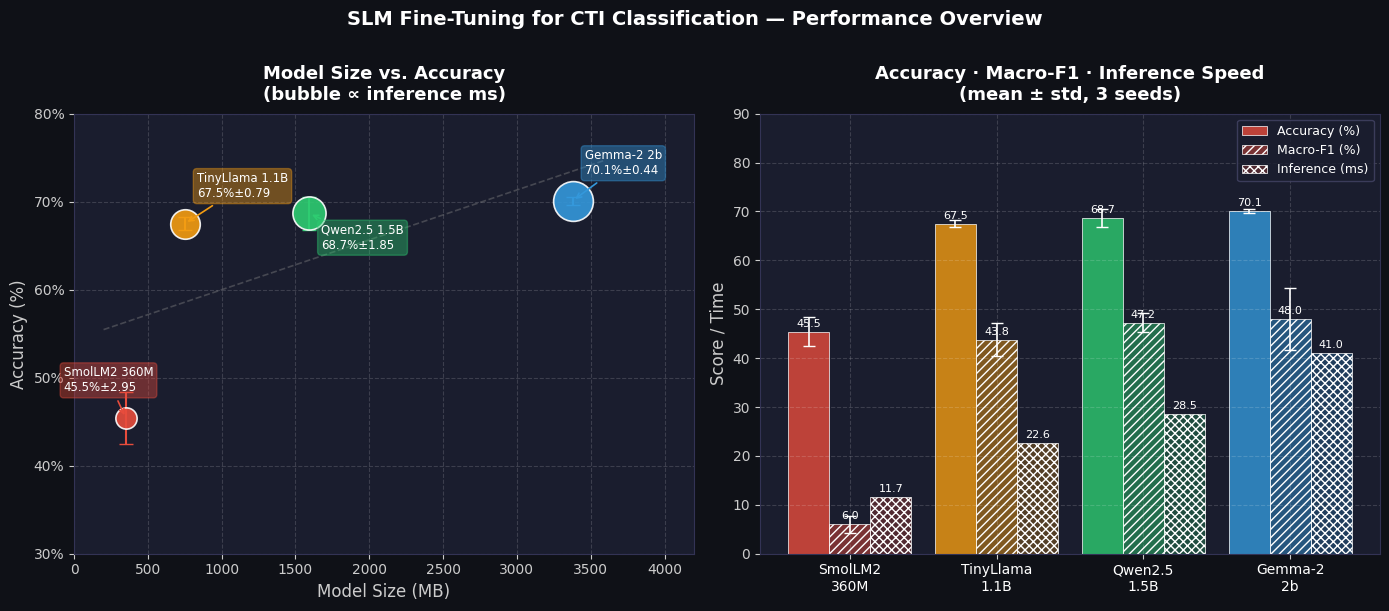

Saved to Drive!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models    = ['SmolLM2\n360M', 'TinyLlama\n1.1B', 'Qwen2.5\n1.5B', 'Gemma-2\n2b']
size_mb   = [350,   752,   1594,  3379]
accuracy  = [45.45, 67.52, 68.66, 70.12]
acc_std   = [2.95,  0.79,  1.85,  0.44]
macro_f1  = [6.01,  43.81, 47.24, 47.98]
f1_std    = [1.80,  3.43,  1.95,  6.37]
inf_ms    = [11.7,  22.6,  28.5,  41.0]
colors    = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')

for ax in (ax1, ax2):
    ax.set_facecolor('#1a1d2e')
    ax.tick_params(colors='#cccccc', labelsize=10)
    ax.xaxis.label.set_color('#cccccc')
    ax.yaxis.label.set_color('#cccccc')
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')
    ax.grid(True, alpha=0.15, color='white', linestyle='--')

# ── Panel 1: Size vs Accuracy scatter ──────────────────────────────
label_offsets = [(-420, 3), (80, 3), (80, -4), (80, 3)]
for i, (m, s, a, sd, c) in enumerate(zip(models, size_mb, accuracy, acc_std, colors)):
    ax1.scatter(s, a, s=inf_ms[i]*20, color=c, edgecolors='white',
                linewidth=1.2, zorder=3, alpha=0.9)
    ax1.errorbar(s, a, yerr=sd, fmt='none', color=c, capsize=5, elinewidth=1.5)
    ox, oy = label_offsets[i]
    ax1.annotate(f"{m.replace(chr(10),' ')}\n{a:.1f}%±{sd:.2f}",
                 xy=(s, a), xytext=(s+ox, a+oy), color='white', fontsize=8.5,
                 bbox=dict(boxstyle='round,pad=0.3', fc=c, alpha=0.4, ec=c),
                 arrowprops=dict(arrowstyle='->', color=c, lw=1.2))

xl = np.linspace(200, 3600, 100)
z  = np.polyfit(size_mb, accuracy, 1)
ax1.plot(xl, np.poly1d(z)(xl), '--', color='#888888', alpha=0.4, lw=1.2)
ax1.set_xlim(0, 4200); ax1.set_ylim(30, 80)
ax1.set_xlabel('Model Size (MB)', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Model Size vs. Accuracy\n(bubble ∝ inference ms)',
              color='white', fontsize=13, fontweight='bold', pad=10)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))

# ── Panel 2: Grouped bars ───────────────────────────────────────────
x, w = np.arange(4), 0.28
b1 = ax2.bar(x-w,   accuracy, w, color=[c+'cc' for c in colors],
             edgecolor='white', lw=0.5, label='Accuracy (%)')
b2 = ax2.bar(x,     macro_f1, w, color=[c+'77' for c in colors],
             edgecolor='white', lw=0.5, hatch='////', label='Macro-F1 (%)')
b3 = ax2.bar(x+w,   inf_ms,   w, color=[c+'44' for c in colors],
             edgecolor='white', lw=0.5, hatch='xxxx', label='Inference (ms)')
ax2.errorbar(x-w, accuracy, yerr=acc_std,
             fmt='none', color='white', capsize=4, elinewidth=1.2)
ax2.errorbar(x,   macro_f1, yerr=f1_std,
             fmt='none', color='white', capsize=4, elinewidth=1.2)

for bars, fmt in [(b1,'{:.1f}'), (b2,'{:.1f}'), (b3,'{:.1f}')]:
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x()+bar.get_width()/2, h+1,
                 fmt.format(h), ha='center', color='white', fontsize=8)

ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=10, color='white')
ax2.set_ylim(0, 90)
ax2.set_ylabel('Score / Time', fontsize=12)
ax2.set_title('Accuracy · Macro-F1 · Inference Speed\n(mean ± std, 3 seeds)',
              color='white', fontsize=13, fontweight='bold', pad=10)
ax2.legend(fontsize=9, facecolor='#1a1d2e', edgecolor='#444466', labelcolor='white')

import os
os.makedirs('/content/drive/MyDrive/BDM_Final_Project/figures', exist_ok=True)

plt.suptitle('SLM Fine-Tuning for CTI Classification — Performance Overview',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/BDM_Final_Project/figures/model_comparison.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Saved to Drive!")
